<a href="https://colab.research.google.com/github/umair594/100-Prediction-Models-/blob/main/Diabetes_Prediction_Using_Random_Forest_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 14: Predicting Continuous Outcomes Using Extra Trees Regressor**

# **Introduction**

Extra Trees Regressor is an ensemble learning algorithm similar to Random Forest but with more randomness. Instead of searching for the optimal split at each node, it chooses splits randomly, which often reduces variance and improves generalization. It’s particularly useful for regression tasks where the target variable is continuous (e.g., house prices, sales, or stock prices).

**Key Features of Extra Trees Regressor:**

Aggregates predictions from multiple randomized decision trees.

Faster to train than standard Random Forest because of random splits.

Reduces overfitting while maintaining high accuracy.

Provides feature importance for interpretability.

Objective: Predict a continuous target variable based on input features using Extra Trees Regressor.

# **Tools and Libraries**

We use Python with the following libraries:

**Data Handling:**

pandas – load and manipulate datasets

numpy – numerical operations

**Data Visualization:**

matplotlib and seaborn – visualize distributions, correlations, and feature importance

**Machine Learning:**

scikit-learn – includes Extra Trees Regressor, train-test split, and evaluation metrics

ExtraTreesRegressor – regression model

GridSearchCV – hyperparameter tuning

metrics – mean squared error, R² score, etc.

**Model Deployment:**

joblib – save and load trained models

# **Dataset**

For this project, a common dataset is Boston Housing or California Housing, which are standard regression datasets with continuous target variables.

Example: Predict house prices based on features like number of rooms, age of the house, population, etc.

# **Step 1: Import Libraries**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib

# **Step 2: Load Dataset**

In [25]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


**Target variable**: MedHouseVal (Median house value)

**Features**: 8 input variables like AveRooms, Population, MedInc, etc.

# **Step 3: Exploratory Data Analysis (EDA)**

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


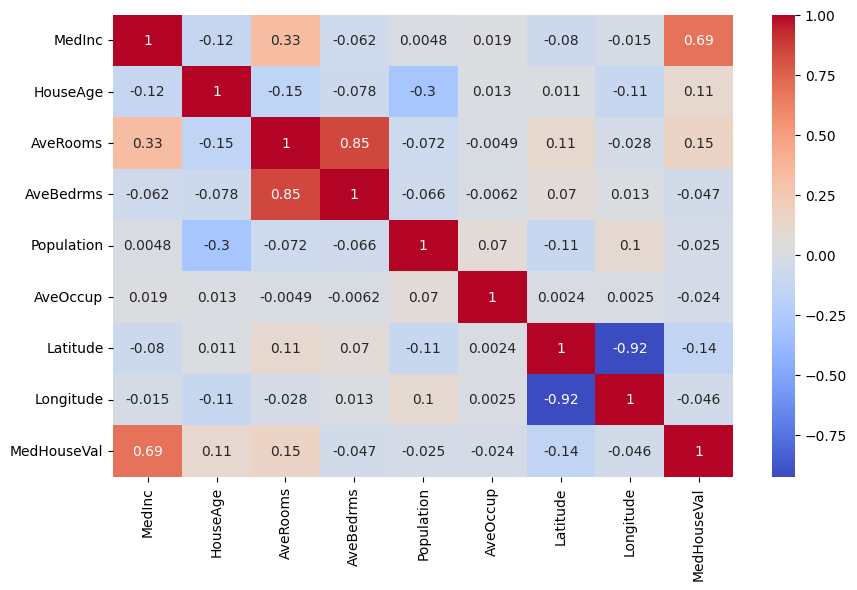

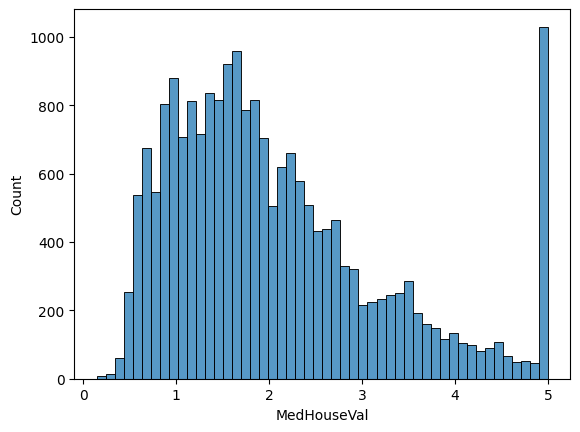

In [26]:
# Check missing values
print(df.isnull().sum())

# Visualize correlations
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Distribution of target variable
sns.histplot(y, bins=50)
plt.show()

# **Step 4: Train-Test Split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 5: Initialize Extra Trees Regressor**

In [28]:
etr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# **Step 6: Train the Model**

In [29]:
etr.fit(X_train, y_train)

ExtraTreesRegressor(random_state=42)

# **Step 7: Make Predictions**

In [30]:
y_pred = etr.predict(X_test)

# **Step 8: Evaluate the Model**

In [31]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.25390365487798505
R² Score: 0.8062409071564614


**Mean Squared Error (MSE)**: lower is better

**R² Score**: closer to 1 indicates better fit

# **Step 9: Feature Importance**

      Feature  Importance
0      MedInc    0.502877
5    AveOccup    0.107864
7   Longitude    0.107787
6    Latitude    0.100091
1    HouseAge    0.071276
2    AveRooms    0.047485
3   AveBedrms    0.034788
4  Population    0.027832


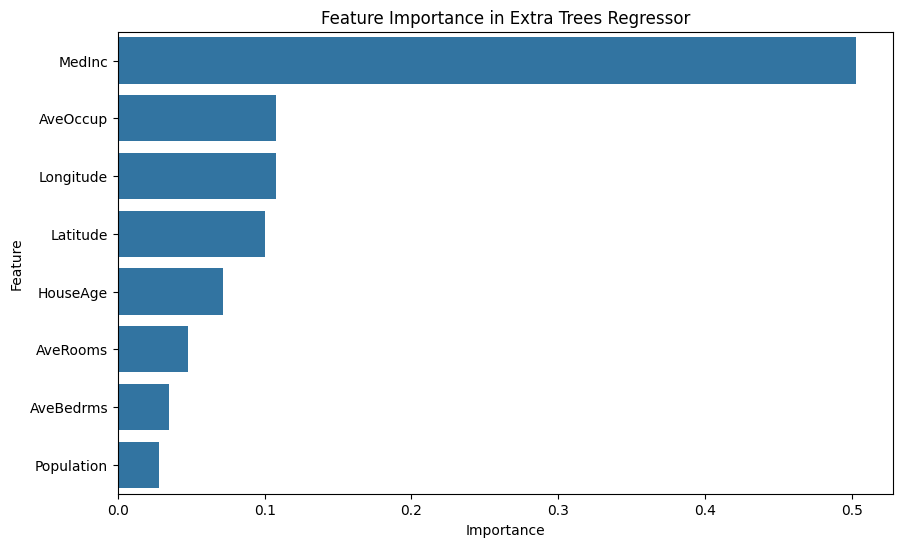

In [32]:
importances = etr.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance in Extra Trees Regressor")
plt.show()

# **Step 10: Hyperparameter Tuning (Optional)**

In [33]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(ExtraTreesRegressor(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_etr = grid.best_estimator_
y_pred_best = best_etr.predict(X_test)
print("R² Score after tuning:", r2_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
R² Score after tuning: 0.8088632128467047


# **Step 11: Save the Model**

In [34]:
joblib.dump(best_etr, "extra_trees_regressor_model.pkl")

['extra_trees_regressor_model.pkl']

# **Expected Results & Insights**

Accuracy: R² score usually ~0.80–0.85 on California Housing dataset.

**Feature Importance:**

MedInc (Median income) often most important.

AveRooms, HouseAge also influential.

Extra Trees Regressor generally produces low variance and robust predictions due to randomization and ensemble averaging.

**Insights:**

Random splits reduce overfitting compared to a single decision tree.

Model helps identify key features affecting the target (house price).

Hyperparameter tuning improves predictive performance slightly.